### Assignment #2 Analyzing cardiovascular disease data

#### Part 1. Preliminary data analysis

In [10]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
import seaborn as sns
sns.set()
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [11]:
sns.set_context(
    "notebook", font_scale=1.5, rc={"figure.figsize": (11, 8), "axes.titlesize": 18}
)

from matplotlib import rcParams

rcParams["figure.figsize"] = 11, 8

In [12]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [13]:
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


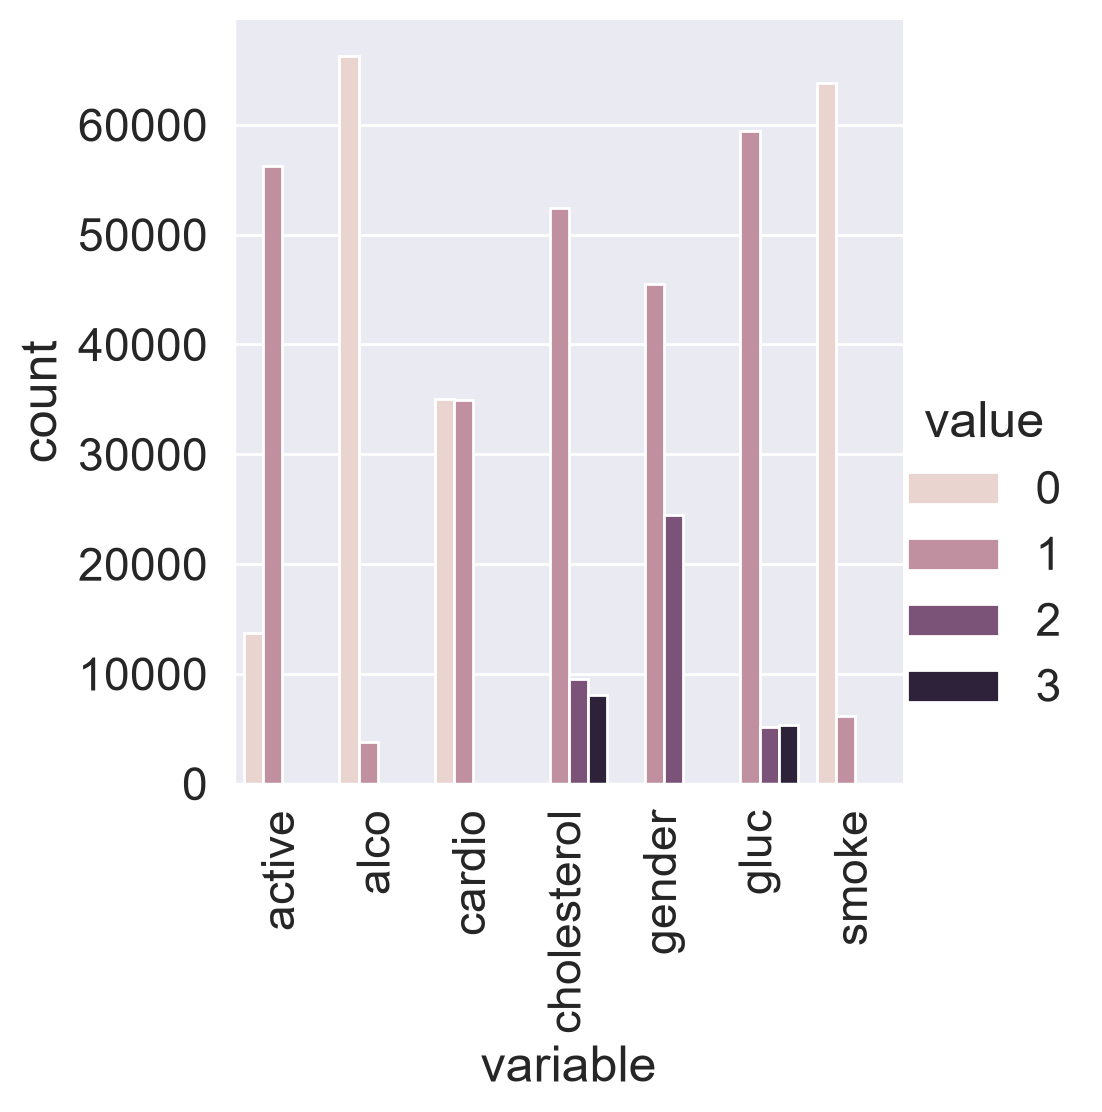

In [14]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"],
)
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    x="variable", y="count", hue="value", data=df_uniques, kind="bar"
)
plt.xticks(rotation='vertical');

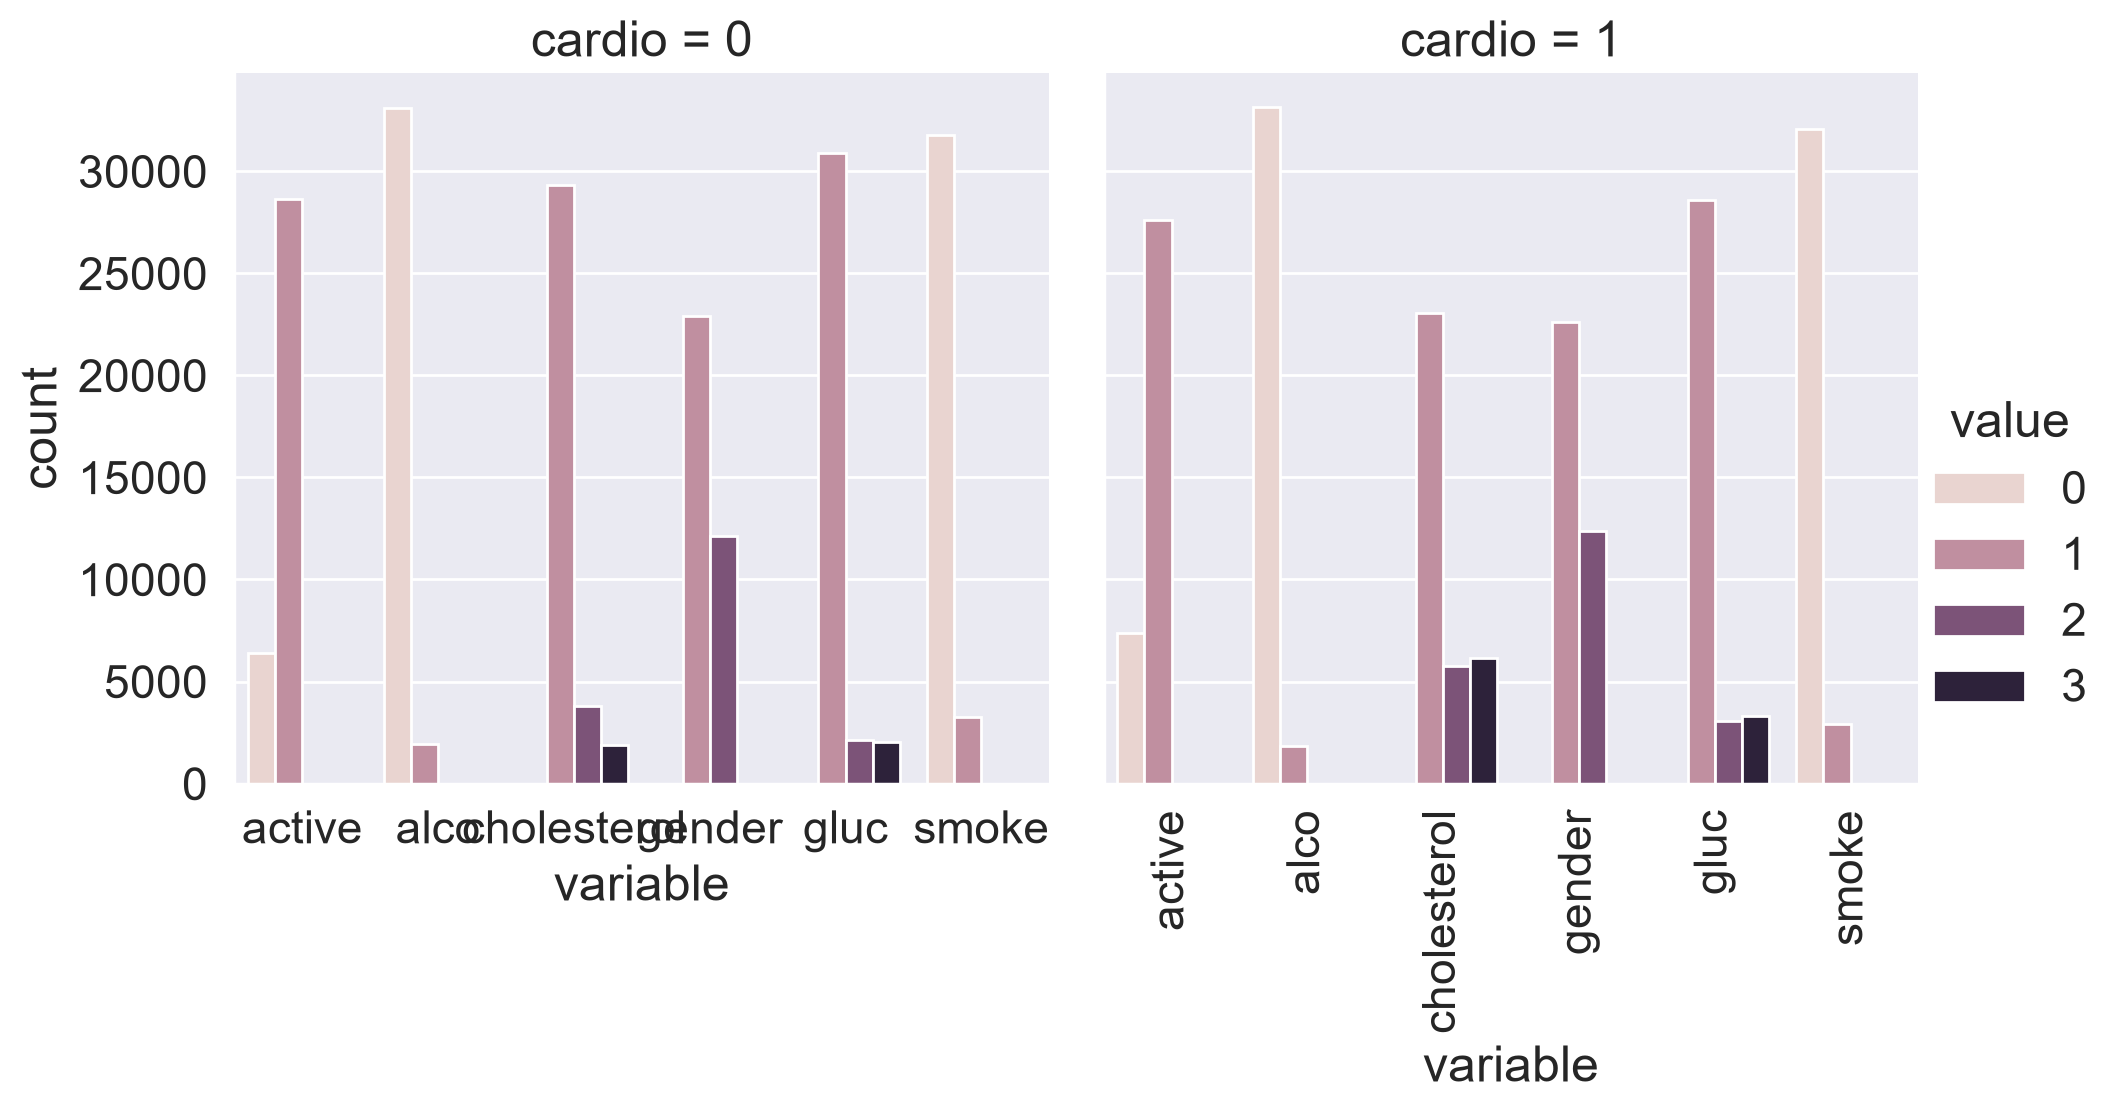

In [15]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"],
)
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="cardio",
    data=df_uniques,
    kind="bar",
)
plt.xticks(rotation='vertical');

In [16]:
for c in df.columns:
    n = df[c].nunique()
    print(c)
    if n <= 3:
        print(n, sorted(df[c].value_counts().to_dict().items()))
    else:
        print(n)
    print(10 * "-")

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
----------
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
----------
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
----------
smoke
2 [(0, 63831), (1, 6169)]
----------
alco
2 [(0, 66236), (1, 3764)]
----------
active
2 [(0, 13739), (1, 56261)]
----------
cardio
2 [(0, 35021), (1, 34979)]
----------


### 1.1. Basic observations

#### Question 1.1.
(1 point). How many men and women are present in this dataset? Values of the gender feature were not given (whether “1” stands for women or for men) – figure this out by analyzing height, making the assumption that men are taller on average.

In [18]:
df.groupby('gender')['height'].mean()
# 1 == female
# 2 == male

gender
1    161.355612
2    169.947895
Name: height, dtype: float64

#### Question 1.2. 
(1 point). Who more often report consuming alcohol – men or women?

In [23]:
df.groupby('gender')['alco'].mean()
# 2 == male's are more often consuming alcohol.

gender
1    0.025500
2    0.106375
Name: alco, dtype: float64

#### Question 1.3.
(1 point). What’s the rounded difference between the percentages of smokers among men and women?

In [28]:
smoke = df.groupby('gender')['smoke'].mean() * 100
smoke.round()
# %20 

gender
1     2.0
2    22.0
Name: smoke, dtype: float64

#### Question 1.4.
(1 point). What’s the rounded difference between median values of age (in months) for non-smokers and smokers? You’ll need to figure out the units of feature age in this dataset.

In [49]:
age1 = df['age'] / 12
smoke1 = df['smoke'] == 1  
smoke0 = df['smoke'] == 0
df.groupby('smoke')['age'].median()
# smokers lower than non-smokers 

smoke
0    19722.0
1    19125.0
Name: age, dtype: float64

#### 1.2. Risk maps

##### Task:
On the website for the European Society of Cardiology, a SCORE scale is provided. It is used for calculating the risk of death from a cardiovascular decease in the next 10 years. Here it is:

Let’s take a look at the upper-right rectangle, which shows a subset of smoking men aged from 60 to 65. (It’s not obvious, but the values in the figure represent the upper bound).

We see the value 9 in the lower-left corner of the rectangle and 47 in the upper-right. This means that, for people in this gender-age group whose systolic pressure is less than 120, the risk of a CVD is estimated to be 5 times lower than for those with the pressure in the interval [160,180).

Let’s calculate that same ratio using our data.

Clarifications:

Calculate age_years feature – round age to the nearest number of years. For this task, select only the people of age 60 to 64, inclusive.

Cholesterol level categories differ between the figure and our dataset. The conversion for the cholesterol feature is as follows: 4 mmol/l 
 1, 5-7 mmol/l 
 2, 8 mmol/l

In [86]:
df['age_years'] = (df['age'] / 365.25).round().astype(int)
subset = df[
    (df['age_years'] >= 60) &
    (df['age_years'] <= 64) &
    (df['gender'] == 2) &
    (df['smoke'] == 1) 
    ]
risk_low = subset[subset['ap_hi'] < 120]['cardio'].mean()
risk_high = subset[(subset['ap_hi'] >= 160) & (subset['ap_hi'] < 180)]['cardio'].mean()
ratio = risk_high / risk_low
print(ratio)

2.607142857142857


#### 1.3. Analyzing BMI

##### Task:
Create a new feature – BMI (Body Mass Index). To do this, divide weight in kilograms by the square of the height in meters. Normal BMI values are said to be from 18.5 to 25.

In [91]:
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2
df['BMI']

0        21.967120
1        34.927679
2        23.507805
3        28.710479
4        23.011177
           ...    
69995    26.927438
69996    50.472681
69997    31.353579
69998    27.099251
69999    24.913495
Name: BMI, Length: 70000, dtype: float64

#### Question 1.6.
(2 points). Choose the correct statements:
1.Median BMI in the sample is within boundaries of normal values.

2.Women’s BMI is on average higher than men’s.

3.Healthy people have higher median BMI than ill people.

4.In the segment of healthy and non-drinking men BMI is closer to the norm than in the segment of healthy and non-drinking women

In [93]:
df['BMI'].median()
df.groupby('gender')['BMI'].mean()
df.groupby('cardio')['BMI'].median
# 2 and 4

<bound method GroupBy.median of <pandas.api.typing.SeriesGroupBy object at 0x00000217362B6D00>>

#### 1.4. Cleaning data

##### Task:
We can see that the data is not perfect. It contains “dirt” and inaccuracies. We’ll see this better as we visualize the data.

Filter out the following patient segments (we consider these as erroneous data)

- diastolic pressure is higher than systolic.

- height is strictly less than 2.5 percentile (Use pd.Series.quantile to compute this - value. If you are not familiar with the function, please read the docs.)

- height is strictly more than 97.5 percentile

- weight is strictly less than 2.5 percentile

- weight is strictly more than 97.5 percentile

This is not everything that we can do to clean this data, but this is sufficient for now.

In [95]:
h_low = df['height'].quantile(0.025)
h_high = df['height'].quantile(0.975)
w_low = df['weight'].quantile(0.025)
w_high = df['weight'].quantile(0.975)

df_filtered = df[
    (df['ap_lo'] <= df['ap_hi']) & 
    (df['height'] >= h_low) & 
    (df['height'] <= h_high) & 
    (df['weight'] >= w_low) & 
    (df['weight'] <= w_high)
]

##### Question 1.7.
(2 points). What percent of the original data (rounded) did we filter out in the previous step?

In [102]:
original_count = len(df) 
filtered_count = len(df_filtered) 
percentage_dropped = (1 - filtered_count / original_count) * 100
print(f"{percentage_dropped:.2f}%")

9.63%


#### Part 2. Visual data analysis 

#### 2.1. Correlation matrix visualization
To understand the features better, you can create a matrix of the correlation coefficients between the features. Use the filtered dataset from now on.

##### Task:
Plot a correlation matrix using heatmap(). You can create the matrix using the standard pandas tools with the default parameters.

<Axes: >

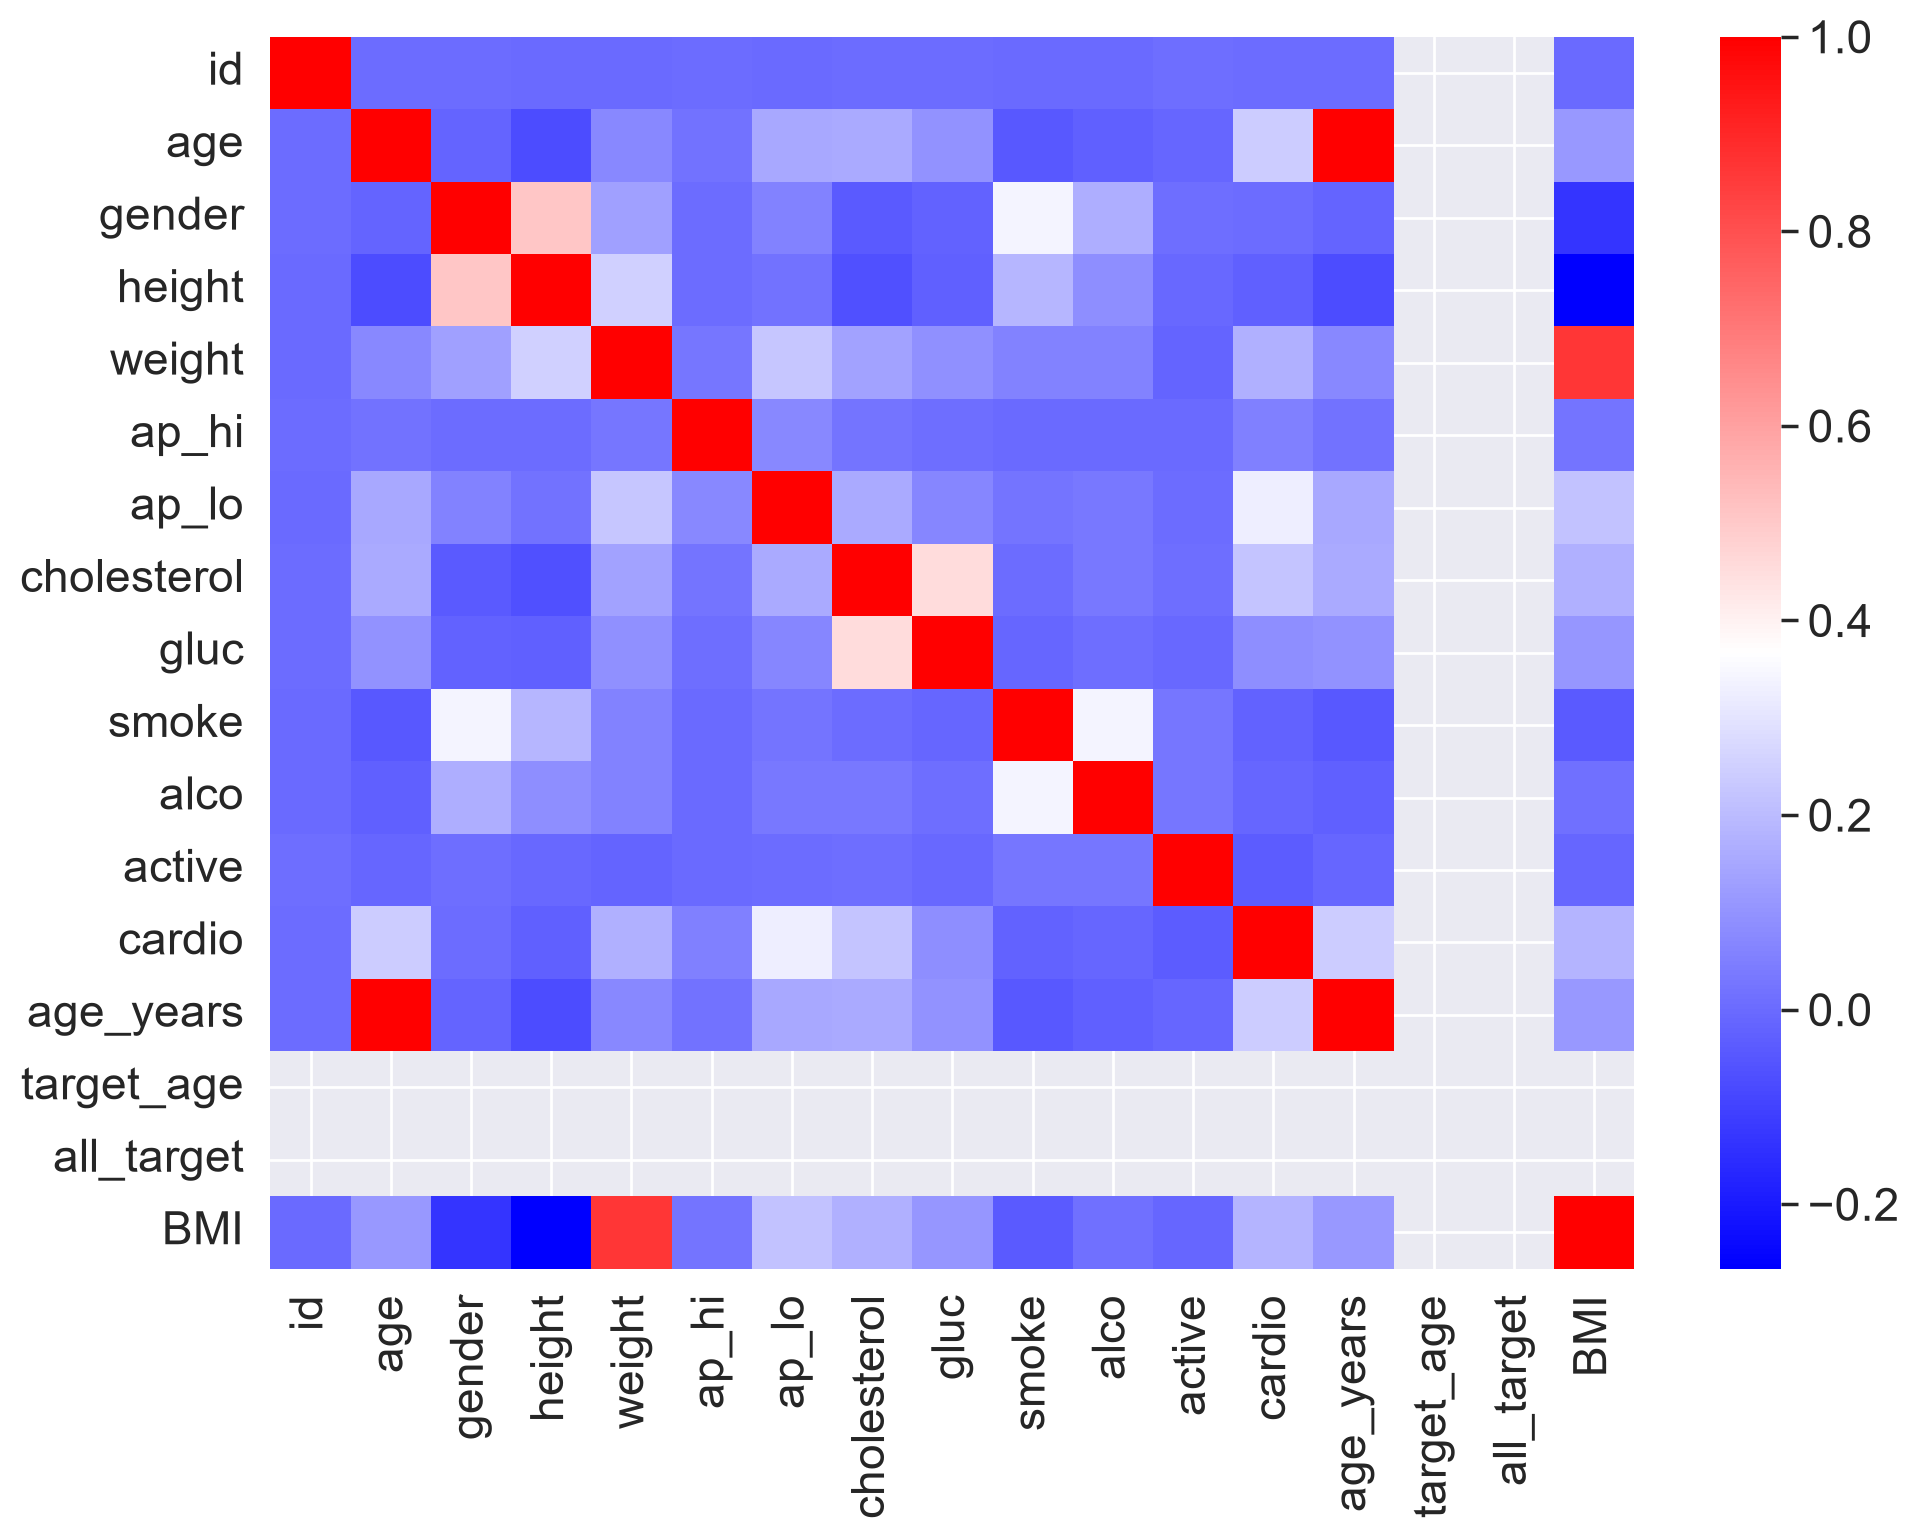

In [112]:
corr = df_filtered.corr()
sns.heatmap(corr, cmap='bwr') 

##### Question 2.1. (1 point). Which pair of features has the strongest Pearson’s correlation with the gender feature?

1.Cardio, Cholesterol

2.Height, Smoke

3.Smoke, Alco

4.Height, Weight

In [113]:
# 3-Smoke,Alco

#### 2.2. Height distribution of men and women
From our exploration of the unique values earlier, we know that the gender is encoded by the values 1 and 2. Although you do not know the mapping of these values to gender, you can figure that out graphically by looking at the mean values of height and weight for each value of the gender feature.

##### Task:
Create a violin plot for the height and gender using violinplot(). Use the parameters:

hue to split by gender;

scale to evaluate the number of records for each gender.

In order for the plot to render correctly, you need to convert your DataFrame to long format using the melt() function from pandas. Here is an example of this for your reference.

<Axes: xlabel='variable', ylabel='value'>

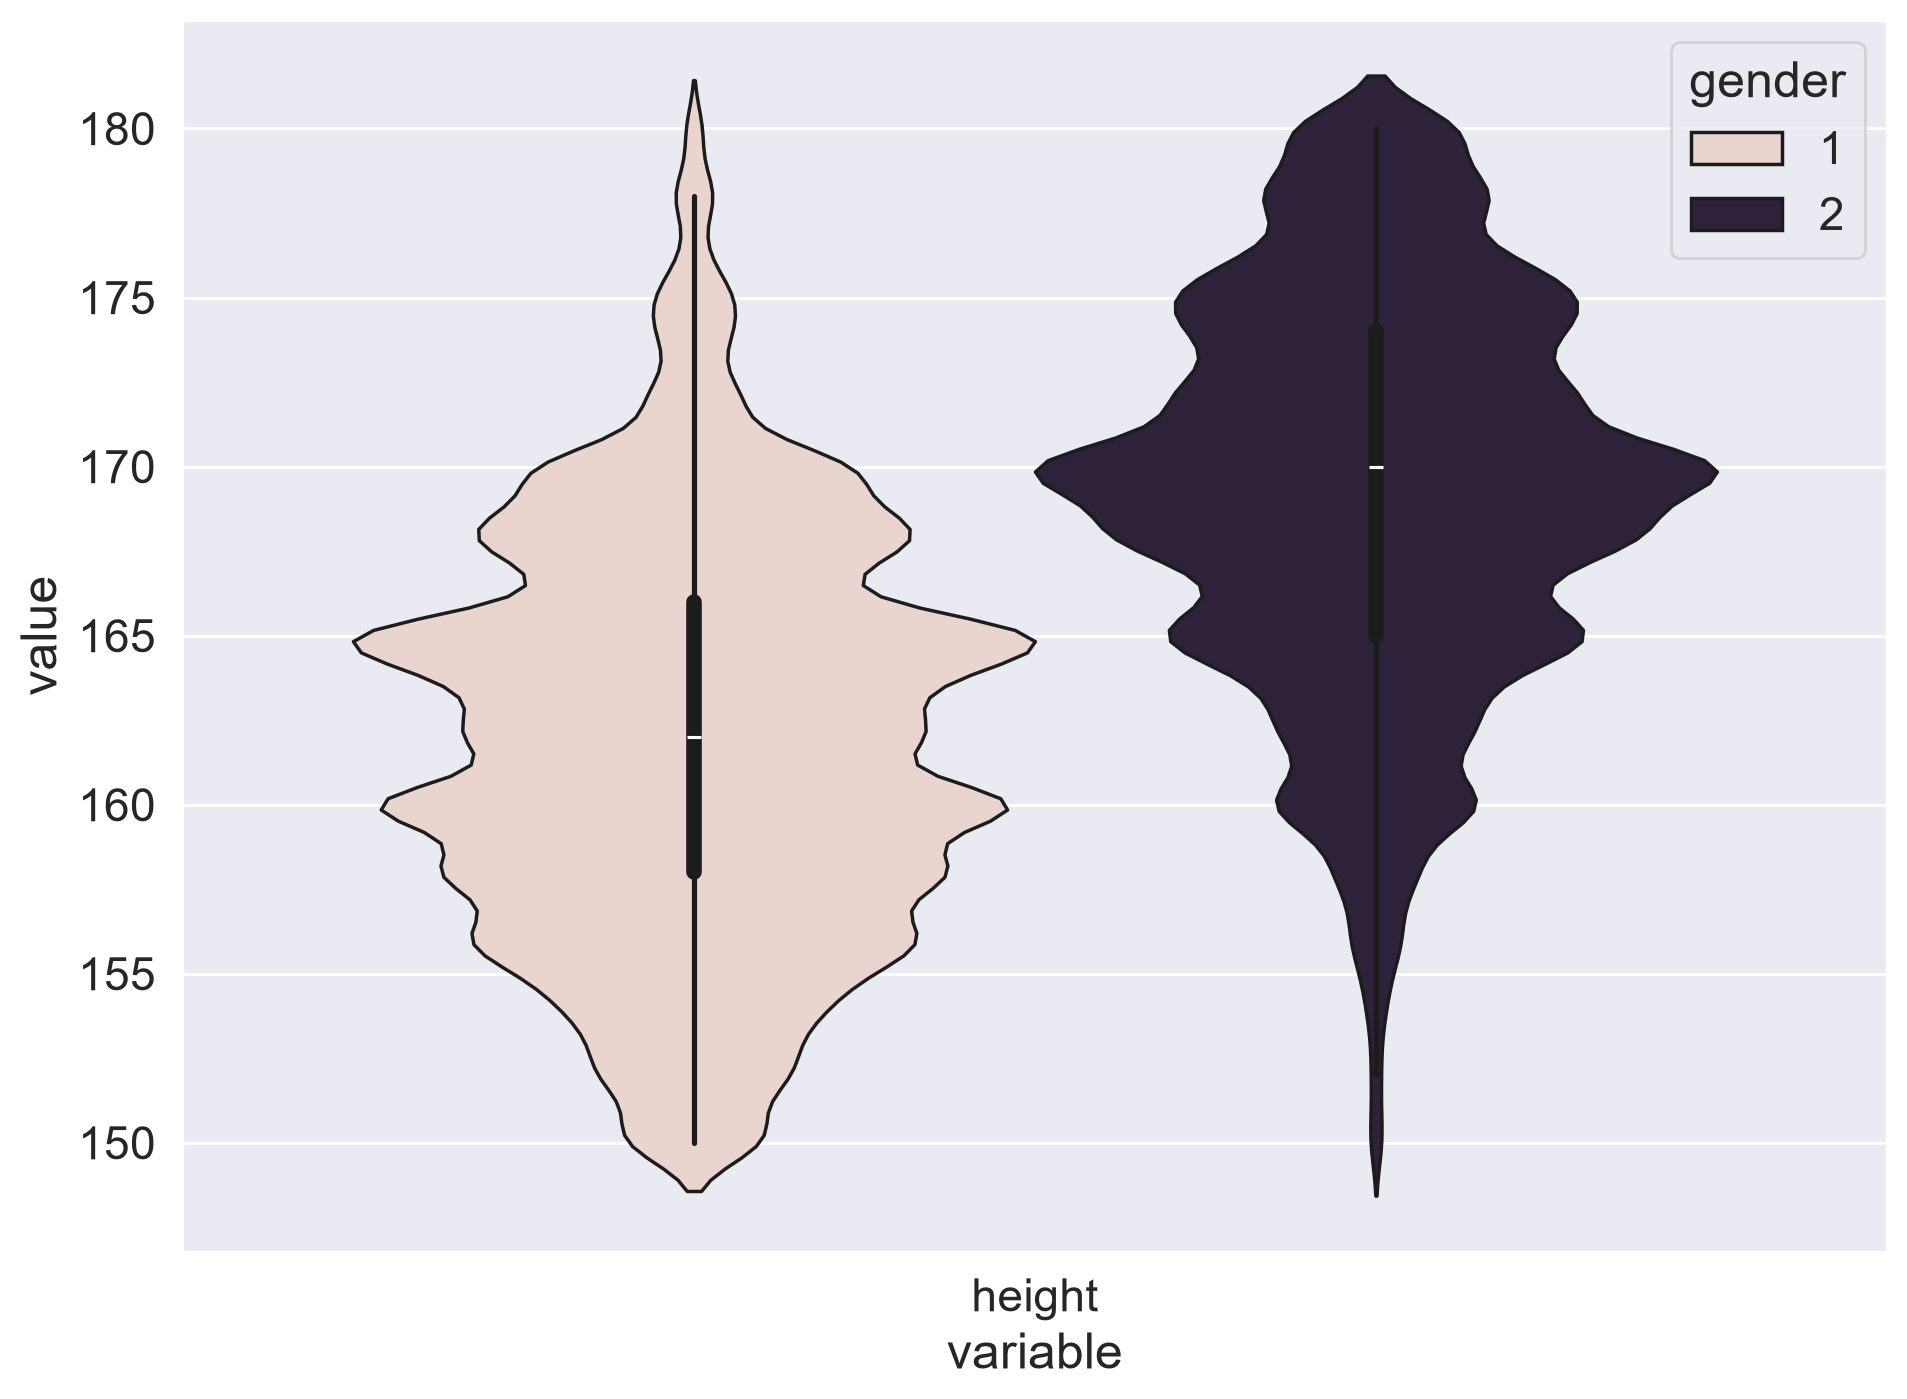

In [122]:
melt = pd.melt(df_filtered, id_vars=['gender'], value_vars=['height'])
sns.violinplot(data = melt,scale='count',x='variable',y='value',hue='gender')

#### 2.3. Rank correlation
In most cases, the Pearson coefficient of linear correlation is more than enough to discover patterns in data. But let’s go a little further and calculate a rank correlation. It will help us to identify such feature pairs in which the lower rank in the variational series of one feature always precedes the higher rank in the other one (and we have the opposite in the case of negative correlation).

##### Task:
Calculate and plot a correlation matrix using the Spearman’s rank correlation coefficient.

<Axes: >

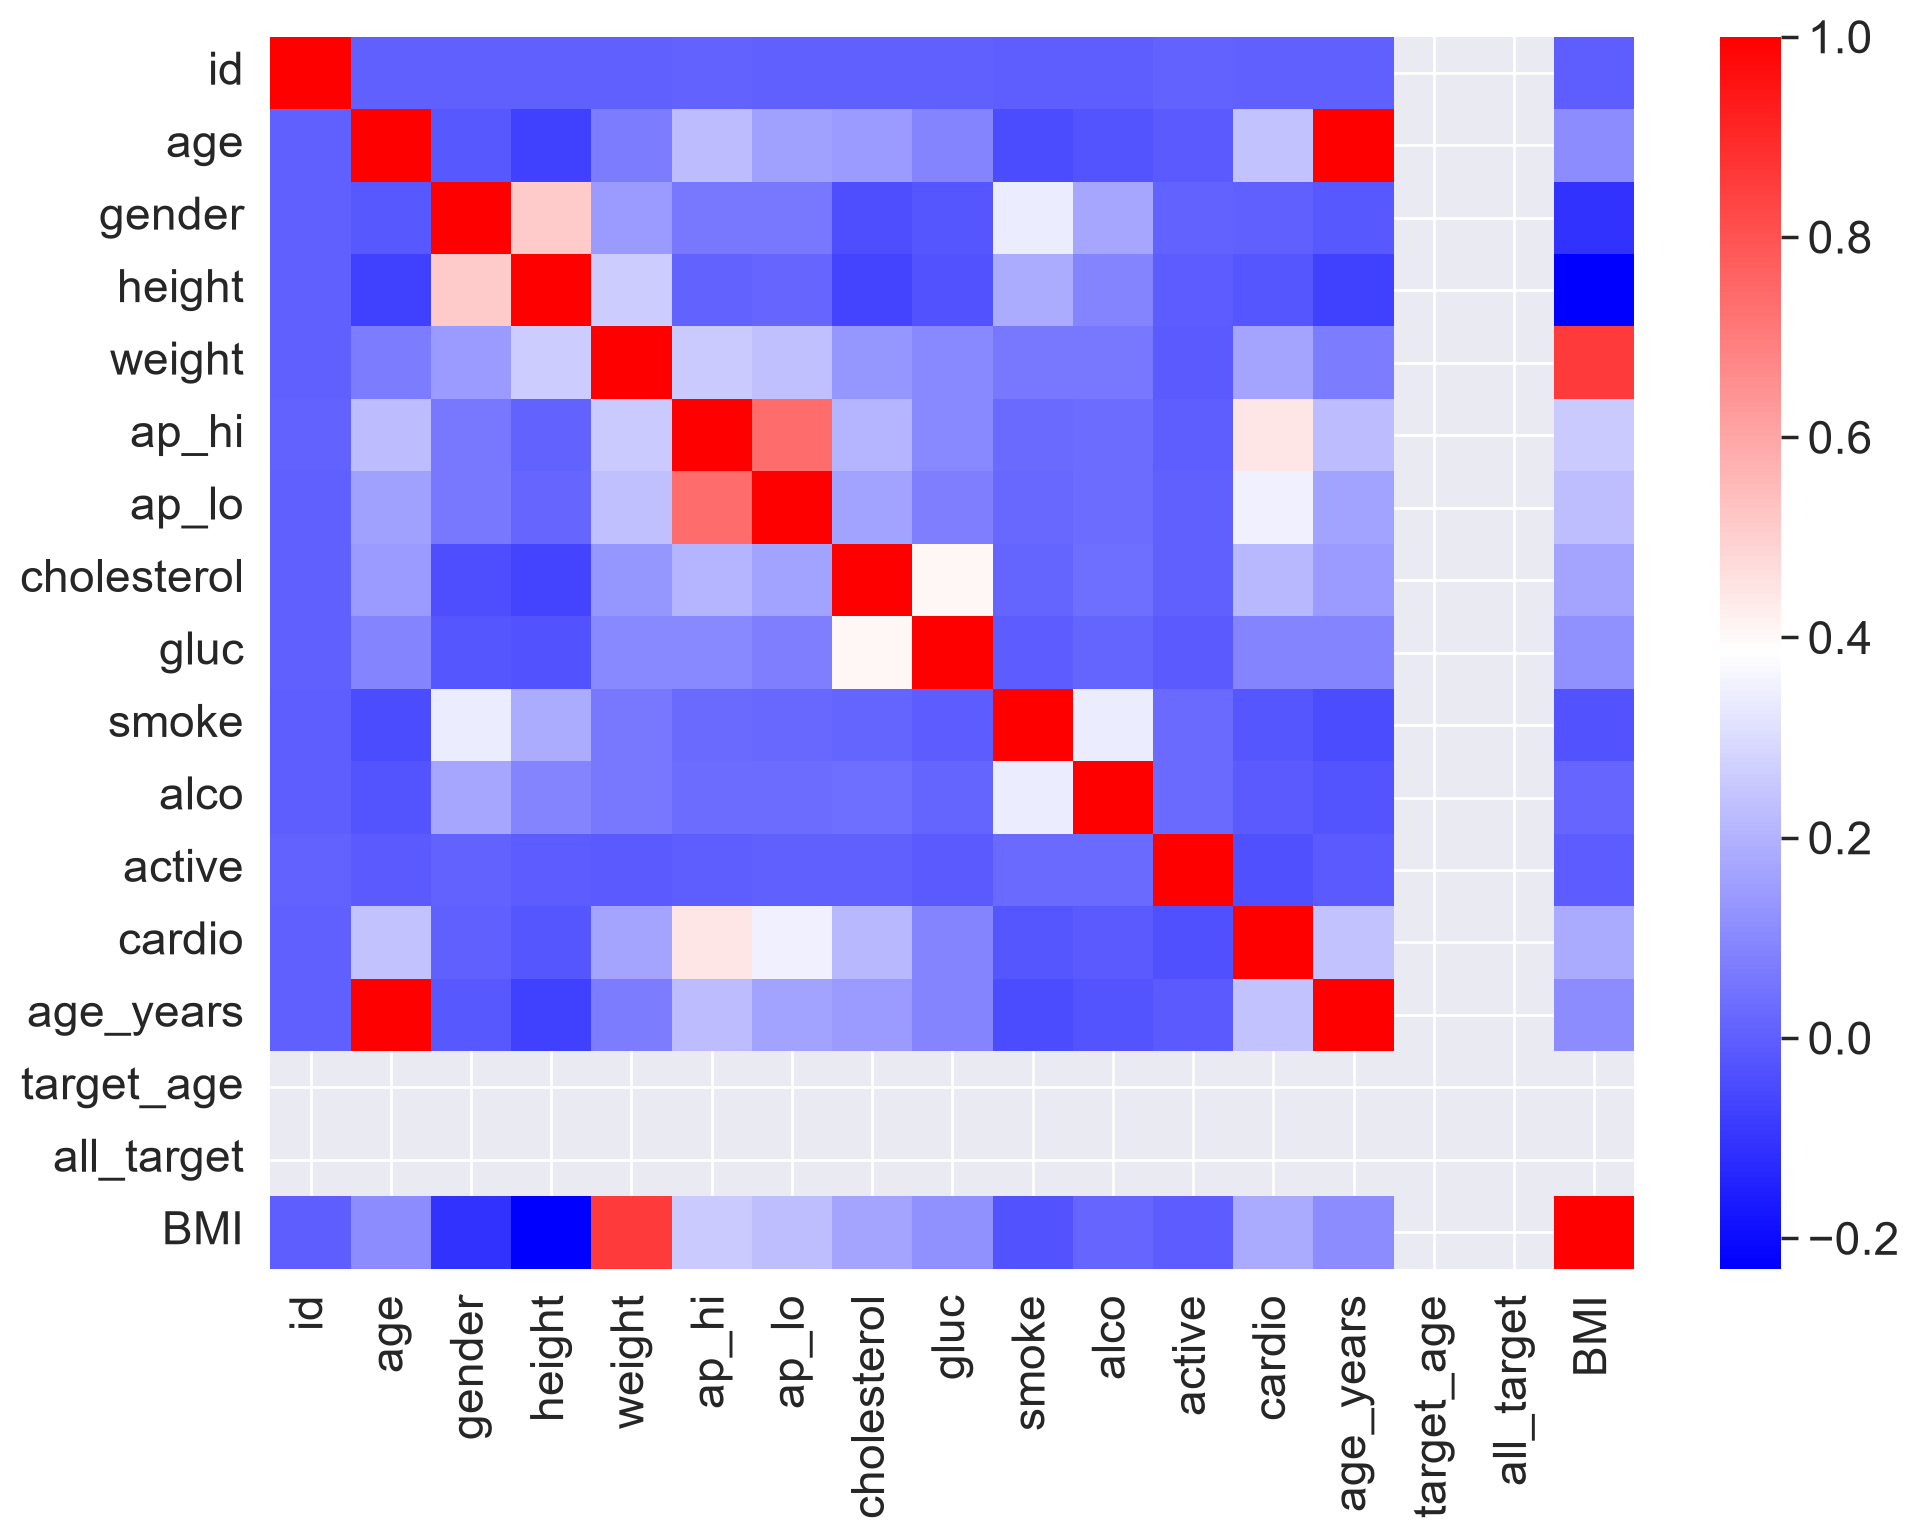

In [127]:
spear = df_filtered.corr(method='spearman')
sns.heatmap(data = spear,cmap='bwr')

#### Question 2.2. (1 point). Which pair of features has the strongest Spearman rank correlation?
1.Height, Weight

2.Age, Weight

3.Cholesterol, Gluc

4.Cardio, Cholesterol

5.Ap_hi, Ap_lo

6.Smoke, Alco

In [128]:
#Ap_hi, Ap_lo

#### Question 2.3. (1 point). Why do these features have strong rank correlation?

1.Inaccuracies in the data (data acquisition errors).

2.Relation is wrong, these features should not be related.

3.Nature of the data.

In [129]:
# Systolic and diastolic blood pressures are biologically and physiologically linked within the human cardiovascular system, which naturally causes them to move together, 
#resulting in a strong rank correlation

#### 2.4. Age
Previously, we calculated the age of the respondents in years at the moment of examination.

##### Task:
Create a count plot using countplot() with the age on the X axis and the number of people on the Y axis. Your resulting plot should have two columns for each age, corresponding to the number of people for each cardio class of that age.

<Axes: xlabel='age_years', ylabel='count'>

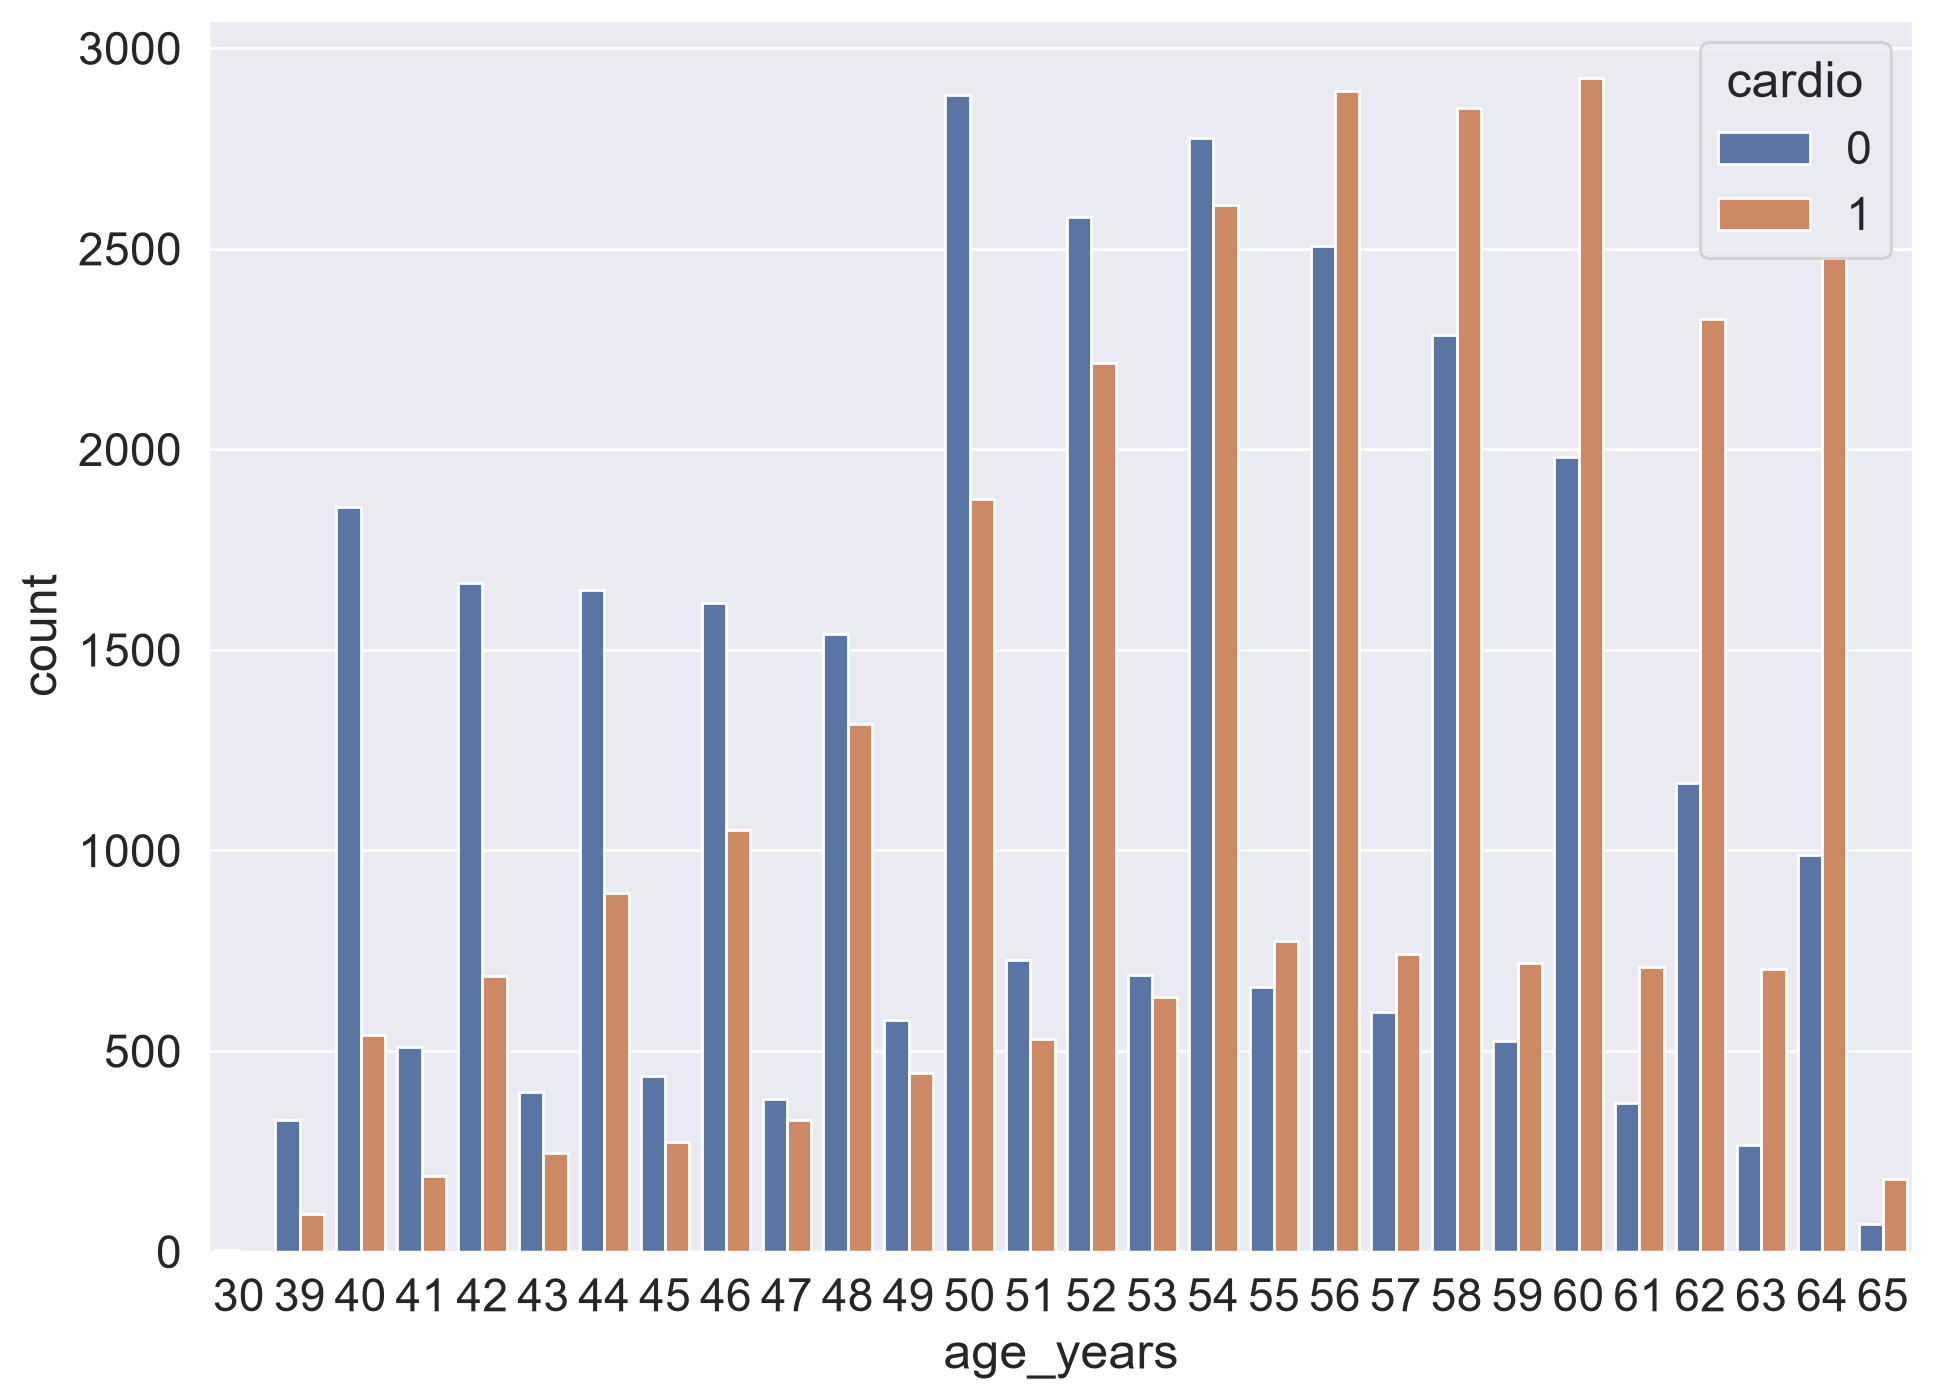

In [136]:
sns.countplot(data = df_filtered, x = 'age_years', hue = 'cardio')

#### Question 2.4. (1 point). What is the smallest age at which the number of people with CVD outnumbers the number of people without CVD?
1.44

2.55

3.64

4.70

In [137]:
#2.55